In [1]:
from time import time

import numpy as np

from quantum_simulation.configs import jpc_config_dudas, quantum_parameters_dudas, base_encoding
from quantum_simulation.simulator import Simulator

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = \sqrt{\kappa_a}  \left( \epsilon_a^* a + \epsilon_a a^\dagger \right) + \sqrt{\kappa_b}  \left( \epsilon_b^* b + \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \left[ \sqrt{\kappa_a}\; a \;, \;  \sqrt{\kappa_b}\; b \; , \; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) \right]$$


In [2]:
X = np.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7])
X = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

simulator = Simulator(jpc_config=jpc_config_dudas, encoding=base_encoding)

jpc_config_dudas.summary()
quantum_parameters_dudas.summary()
base_encoding.summary()

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)
QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)
Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)


In [3]:
t1 = time()
A_epsilon = simulator(X, [quantum_parameters_dudas])
print(time() - t1)
#c-profile

|██████████| 100.0% ◆ elapsed 10.49s ◆ remaining 0.00ms  


20.040618658065796


C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


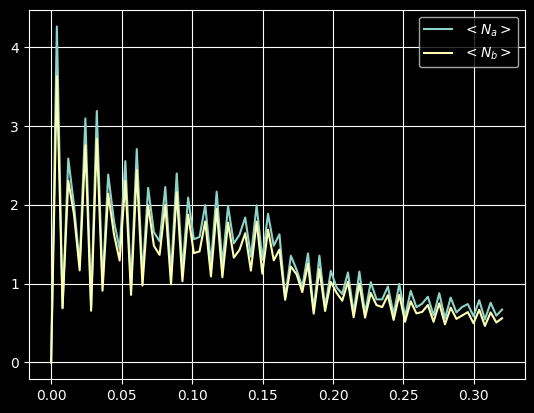

In [4]:
l = A_epsilon[0].photon_distribution.Plot_Mean_Photon_Number()

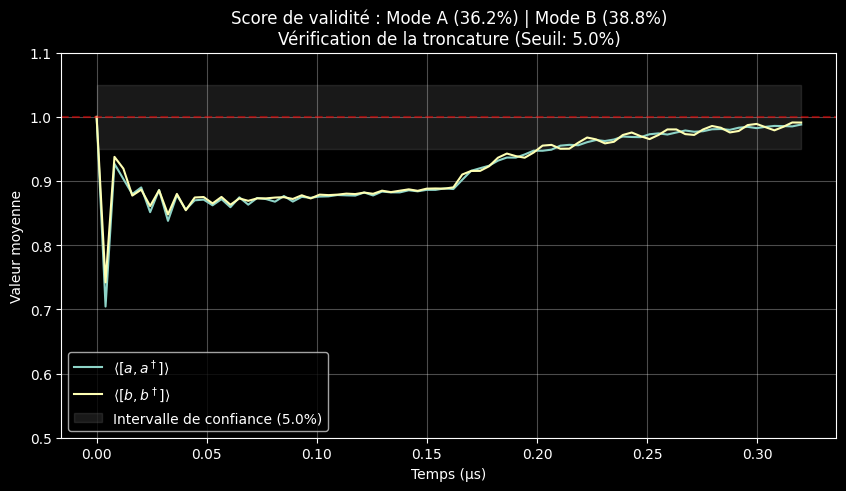

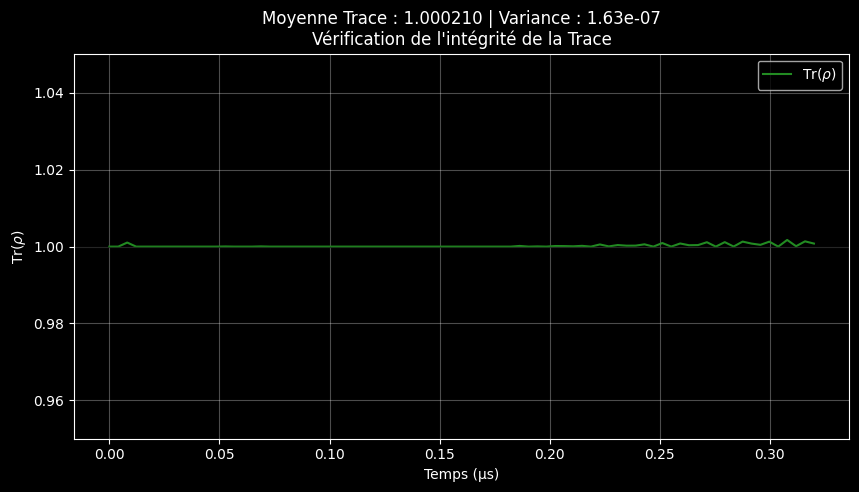

In [5]:
A_epsilon[0].plot_commutator_verification()
A_epsilon[0].plot_trace_integrity()

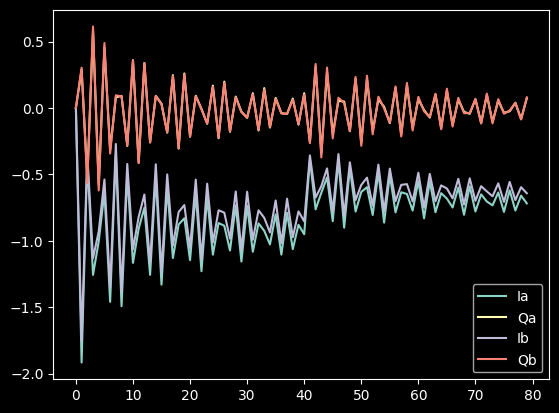

In [6]:
A_epsilon[0].quadratures.plot()

In [7]:
import numpy as np
import sys

# Pour afficher TOUT le tableau sans troncature
np.set_printoptions(threshold=sys.maxsize)

# Pour afficher un nombre précis de chiffres après la virgule (ex: 4)
np.set_printoptions(precision=4, suppress=True)

print(A_epsilon[0].quadratures.L_Ia.reshape(10, -1))

[[ 0.     -1.9167 -0.3855 -1.2568 -1.0053 -0.6319 -1.4602 -0.3499]
 [-1.4928 -0.5033 -1.1663 -0.9087 -0.751  -1.2566 -0.5232 -1.3304]
 [-0.5985 -1.1296 -0.8775 -0.8301 -1.1454 -0.6423 -1.2294 -0.6718]
 [-1.1046 -0.8663 -0.8867 -1.0733 -0.7331 -1.1566 -0.7352 -1.0825]
 [-0.8687 -0.9251 -1.0274 -0.8014 -1.1041 -0.7887 -1.0628 -0.8793]
 [-0.9506 -0.3899 -0.7636 -0.6385 -0.5225 -0.8525 -0.3946 -0.901 ]
 [-0.4509 -0.78   -0.6321 -0.5962 -0.8057 -0.4822 -0.8629 -0.5056]
 [-0.7861 -0.6345 -0.6476 -0.7725 -0.549  -0.8308 -0.5515 -0.785 ]
 [-0.6412 -0.682  -0.7492 -0.5991 -0.8041 -0.5893 -0.7795 -0.6501]
 [-0.7043 -0.7333 -0.6362 -0.7827 -0.6199 -0.7721 -0.6597 -0.7182]]


In [8]:
%matplotlib widget

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
A_epsilon[0].photon_distribution.plot_joint_proba(use_log=True)

In [ ]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='a')

In [ ]:
A_epsilon[0].photon_distribution.plot_marginal_proba(mode='b', use_log=True)

In [ ]:
A_epsilon[0].photon_distribution.P_b[-1]

In [ ]:
import sympy as sp
from IPython.display import display, Math

# Variables
k1, k2 = sp.symbols('kappa1 kappa2', real=True)
g, gs = sp.symbols('g gs')

# Modules au carré
g2 = sp.Abs(g) ** 2
gs2 = sp.Abs(gs) ** 2

# Coefficients
p = g2 + gs2 + (k1 ** 2 + k2 ** 2) / 4
q = (-g2 + gs2 - k1 * k2 / 4) ** 2

# lambda^2
x_plus = (-p + sp.sqrt(p ** 2 - 4 * q)) / 2
x_minus = (-p - sp.sqrt(p ** 2 - 4 * q)) / 2

# valeurs propres
lambdas = [
    sp.sqrt(x_plus), -sp.sqrt(x_plus),
    sp.sqrt(x_minus), -sp.sqrt(x_minus)
]

# Affichage LaTeX
for lam in lambdas:
    display(Math(sp.latex(sp.simplify(lam))))

In [ ]:
eigs

In [ ]:
sp.latex(eigs)